Epoch 1/40
1406/1406 [==============================] - 11s 5ms/step - loss: 0.0028 - accuracy: 2.7201e-04 - val_loss: 8.5351e-04 - val_accuracy: 0.0000e+00
Epoch 2/40
1406/1406 [==============================] - 7s 5ms/step - loss: 0.0011 - accuracy: 5.5366e-04 - val_loss: 7.4237e-04 - val_accuracy: 0.0000e+00
Epoch 3/40
1406/1406 [==============================] - 7s 5ms/step - loss: 8.3330e-04 - accuracy: 3.7007e-04 - val_loss: 6.5073e-04 - val_accuracy: 0.0000e+00
Epoch 4/40
1406/1406 [==============================] - 7s 5ms/step - loss: 9.5786e-04 - accuracy: 7.6218e-04 - val_loss: 8.3907e-04 - val_accuracy: 0.0000e+00
Epoch 5/40
1406/1406 [==============================] - 7s 5ms/step - loss: 7.9412e-04 - accuracy: 1.3646e-04 - val_loss: 6.9147e-04 - val_accuracy: 0.0000e+00
Epoch 6/40
1406/1406 [==============================] - 7s 5ms/step - loss: 7.3969e-04 - accuracy: 2.9524e-04 - val_loss: 9.0402e-04 - val_accuracy: 0.0000e+00
Epoch 7/40
1406/1406 [=========================

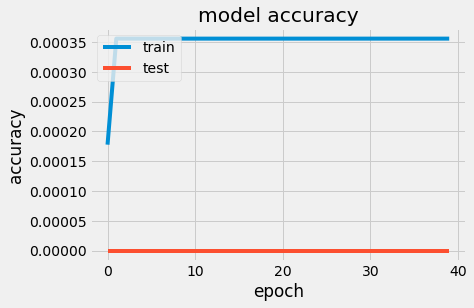

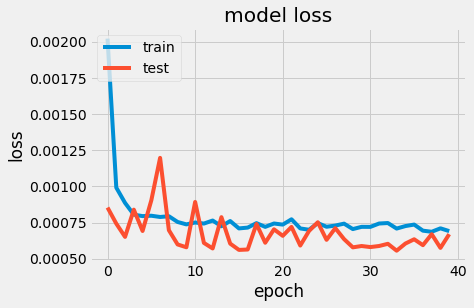

In [4]:
#LSTM
#Import the libraries
import math
import numpy as np
import pandas as pd
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.layers import Dropout
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", header=0)
dataset_x = dataset[['CO', ' PM10', ' NO', ' NO2']].values
dataset_y = dataset[[' PM25']].values

#Split the dataset into training and testing sets (80%:20%)
x_train,x_test,y_train,y_test=train_test_split(dataset_x, dataset_y, test_size=0.2, random_state=42)

#Scale the all of the data to be values between 0 and 1 
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
scaled_xtrain = x_scaler.fit_transform(x_train)
scaled_ytrain = y_scaler.fit_transform(y_train)
scaled_xtest = x_scaler.fit_transform(x_test)

#Convert to numpy arrays
scaled_xtrain, scaled_ytrain = np.array(scaled_xtrain), np.array(scaled_ytrain)

#Reshape the data into 3-D array
scaled_x = np.reshape(scaled_xtrain, (scaled_xtrain.shape[0],scaled_xtrain.shape[1],1))
scaled_y = np.reshape(scaled_ytrain, (scaled_ytrain.shape[0],scaled_ytrain.shape[1],1))

# Initialising the RNN
model_lstm = Sequential()

model_lstm.add(LSTM(units = 100, return_sequences = False, input_shape = (scaled_x.shape[1], 1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units = 1))

#compile and fit the model on 40 epochs
optimizer = keras.optimizers.Adam(lr=0.0001)
model_lstm.compile(optimizer = optimizer, loss = 'mean_squared_error', metrics=['accuracy'])
lstm_history = model_lstm.fit(scaled_x, scaled_y, epochs = 40, batch_size = 4, shuffle=True, validation_split=0.20)

#Convert x_test to a numpy array 
x_test = np.array(scaled_xtest)

#Reshape the data into 3-D array
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

#check predicted values
predictions = model_lstm.predict(x_test)
x_pred = model_lstm.predict(scaled_x)

#Undo scaling
predictions = y_scaler.inverse_transform(predictions)
x_pred = y_scaler.inverse_transform(x_pred)
#print(predictions.shape)

#Calculate RMSE score
rmse_test=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse_train=np.sqrt(np.mean(((x_pred- y_train)**2)))
print("training rmse: ", rmse_train)
print("testing rmse: ", rmse_test)

# list all data in history
print(lstm_history.history.keys())
print("\n")

# summarize history for accuracy
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Epoch 1/40
1406/1406 [==============================] - 11s 6ms/step - loss: 0.0025 - accuracy: 6.1655e-06 - val_loss: 8.7774e-04 - val_accuracy: 0.0000e+00
Epoch 2/40
1406/1406 [==============================] - 8s 6ms/step - loss: 8.7420e-04 - accuracy: 7.2319e-04 - val_loss: 7.5722e-04 - val_accuracy: 0.0000e+00
Epoch 3/40
1406/1406 [==============================] - 8s 5ms/step - loss: 9.2336e-04 - accuracy: 1.4213e-04 - val_loss: 8.8813e-04 - val_accuracy: 0.0000e+00
Epoch 4/40
1406/1406 [==============================] - 7s 5ms/step - loss: 8.9436e-04 - accuracy: 9.7795e-04 - val_loss: 8.7036e-04 - val_accuracy: 0.0000e+00
Epoch 5/40
1406/1406 [==============================] - 6s 5ms/step - loss: 8.6950e-04 - accuracy: 1.8366e-04 - val_loss: 9.0533e-04 - val_accuracy: 0.0000e+00
Epoch 6/40
1406/1406 [==============================] - 6s 5ms/step - loss: 9.1345e-04 - accuracy: 4.5227e-04 - val_loss: 0.0011 - val_accuracy: 0.0000e+00
Epoch 7/40
1406/1406 [=========================

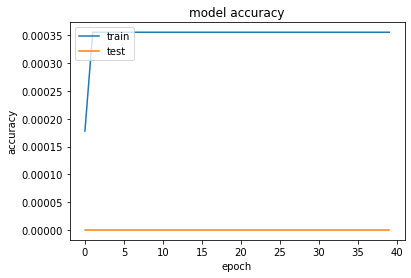

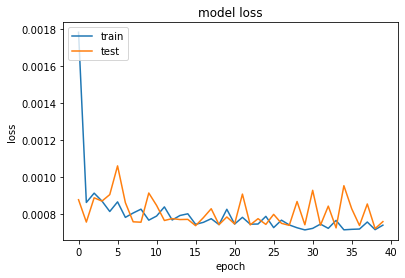

In [5]:
#GRU
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt
from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import GRU
import tensorflow as tf
from datetime import datetime

dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", header=0)
dataset_x = dataset[['CO', ' PM10', ' NO', ' NO2']].values
dataset_y = dataset[[' PM25']].values

#Split the dataset into training and testing sets (80%:20%)
x_train,x_test,y_train,y_test=train_test_split(dataset_x, dataset_y, test_size=0.2, random_state=42)

#Scale the all of the data to be values between 0 and 1 
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
scaled_xtrain = x_scaler.fit_transform(x_train)
scaled_ytrain = y_scaler.fit_transform(y_train)
scaled_xtest = x_scaler.fit_transform(x_test)

#Convert to numpy arrays
scaled_xtrain, scaled_ytrain = np.array(scaled_xtrain), np.array(scaled_ytrain)

#Reshape the data into 3-D array
scaled_x = np.reshape(scaled_xtrain, (scaled_xtrain.shape[0],scaled_xtrain.shape[1],1))
scaled_y = np.reshape(scaled_ytrain, (scaled_ytrain.shape[0],scaled_ytrain.shape[1],1))

model_gru = Sequential()
model_gru.add(GRU(100, return_sequences = False, input_shape = (scaled_x.shape[1], 1)))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(units=1))

#compile and fit the model
optimizer = keras.optimizers.Adam(lr=0.0001)
model_gru.compile(optimizer = optimizer, loss = 'mean_squared_error', metrics=['accuracy'])
gru_history = model_gru.fit(scaled_x, scaled_y, epochs = 40, batch_size = 4, shuffle=True, validation_split=0.2)

#Convert x_test to a numpy array 
x_test = np.array(scaled_xtest)

#Reshape the data into 3-D array
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

#check predicted values
predictions = model_gru.predict(x_test)
x_pred = model_gru.predict(scaled_x)

#Undo scaling
predictions = y_scaler.inverse_transform(predictions)
x_pred = y_scaler.inverse_transform(x_pred)

#Calculate RMSE score
rmse_test=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse_train=np.sqrt(np.mean(((x_pred- y_train)**2)))
print("training rmse: ", rmse_train)
print("testing rmse: ", rmse_test)
print(gru_history.history.keys())
print("\n")

# summarize history for accuracy
plt.plot(gru_history.history['accuracy'])
plt.plot(gru_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(gru_history.history['loss'])
plt.plot(gru_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

training rmse:  2.4611687996429397
testing rmse:  2.830483573985038
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])




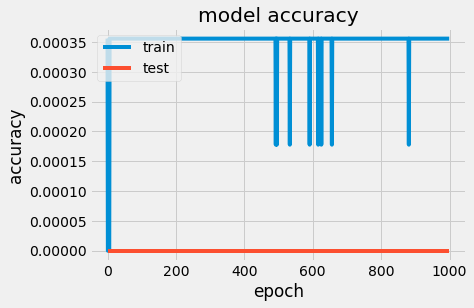

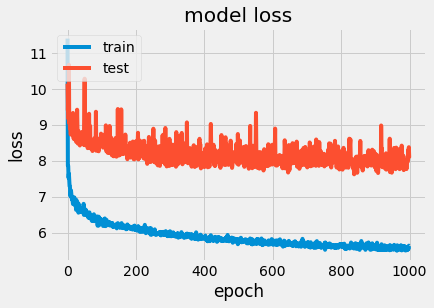

In [6]:
#1D CNN
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from numpy import hstack
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", header=0)
dataset_x = dataset[['CO', ' PM10', ' NO', ' NO2']].values
dataset_y = dataset[[' PM25']].values

#Split the dataset into training and testing sets (80%:20%)
x_train,x_test,y_train,y_test=train_test_split(dataset_x, dataset_y, test_size=0.2)

#Convert to numpy arrays
xtrain, ytrain = np.array(x_train), np.array(y_train)

#Reshape the data into 3-D array
scaled_x = np.reshape(xtrain, (xtrain.shape[0],xtrain.shape[1], 1))
scaled_y = np.reshape(ytrain, (ytrain.shape[0],ytrain.shape[1], 1))

# define model
model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(scaled_x.shape[1], 1)))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(100, activation='relu'))
model_cnn.add(Dense(1))
model_cnn.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

# fit model
cnn_history = model_cnn.fit(scaled_x, scaled_y, epochs=1000, verbose=1, validation_split=0.20)

#Convert x_test to a numpy array 
x_test = np.array(x_test)

#Reshape the data into 3-D array
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

#check predicted values
predictions = model_cnn.predict(x_test, verbose=0)
x_pred = model_cnn.predict(scaled_x, verbose=0)

#Calculate RMSE score
rmse_test=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse_train=np.sqrt(np.mean(((x_pred- y_train)**2)))
print("training rmse: ", rmse_train)
print("testing rmse: ", rmse_test)

# list all data in history
print(cnn_history.history.keys())
print("\n")

# summarize history for accuracy
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

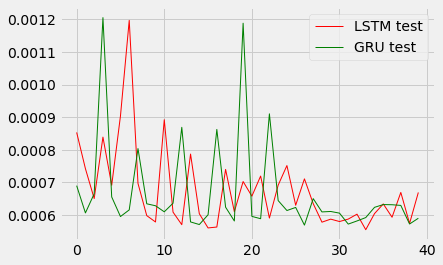

In [12]:
from matplotlib import pyplot
#pyplot.plot(lstm_history.history['loss'], label='LSTM train', color='black', linewidth=1)
pyplot.plot(lstm_history.history['val_loss'], label='LSTM test', color= 'red', linewidth=1)
#pyplot.plot(gru_history.history['loss'], label='GRU train', color='magenta', linewidth=1)
pyplot.plot(gru_history.history['val_loss'], label='GRU test', color='green', linewidth=1)
#pyplot.plot(cnn_history.history['loss'], label='CNN train', color='brown', linewidth=2)
#pyplot.plot(cnn_history.history['loss'], label='CNN test', color='purple', linewidth=2)
pyplot.legend()
pyplot.show()